In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
df= pd.read_csv("./employee_experience.csv")

## 1. Analyzing the dataset for missing values and duplicate values

In [3]:
df.shape

(1500, 2)

In [4]:
df.columns

Index(['Experience_Years', 'Salary'], dtype='str')

In [7]:
df.head(10)

,Experience_Years,Salary
0,8.116262,10175.581957
1,19.063572,36177.242878
2,14.907885,22582.682408
3,NaN,NaN
4,3.964354,10991.672117
5,3.963896,13825.348642
6,NaN,NaN
7,17.457347,30313.838395
8,NaN,NaN
9,14.453379,26386.899585


In [12]:
df.duplicated().sum()

np.int64(449)

In [14]:
df = df.drop_duplicates()

df.shape

(1051, 2)

In [15]:
df.isnull().sum()

Experience_Years    1
Salary              1
dtype: int64

In [16]:
df.isnull().sum().sum()

np.int64(2)

In [18]:
df = df.dropna()

df.isnull().sum().sum()

np.int64(0)

In [19]:
df.shape

(1050, 2)

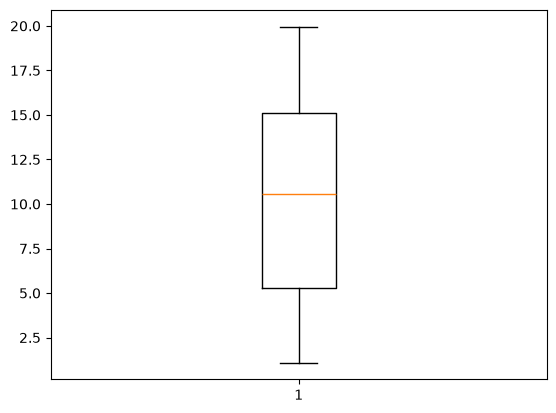

In [28]:
plt.boxplot(df['Experience_Years'])

plt.show()

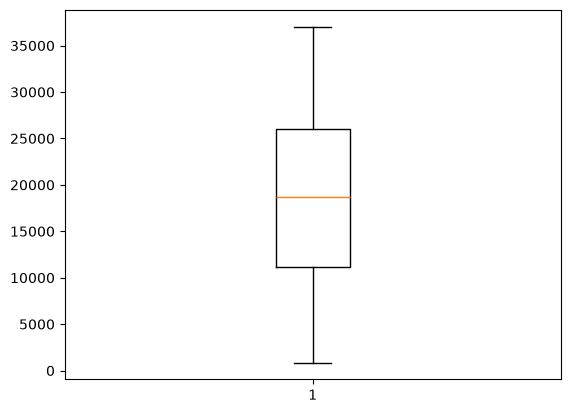

In [29]:
plt.boxplot(df["Salary"])

plt.show()

Dropped the duplicate values found in the dataset and then the missing values count was very less so dropped the missing values 

## 2. Creating the model

In [21]:
X = df[["Experience_Years"]]
Y = df["Salary"]

In [27]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

model = LinearRegression()

model.fit(X_train, Y_train)

(840, 1)
(210, 1)
(840,)
(210,)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[1499.21]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Experience_Years']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3119
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [31]:
print("Intercept(c): ", model.intercept_)
print("Slope (m): ", model.coef_[0])

Intercept(c):  3119.4702585751947
Slope (m):  1499.2107214280243


## 3. Checking the Metrics

In [ ]:
y_pred = model.predict(X_test)

r2 = r2_score(Y_test, y_pred)
mae = mean_absolute_error(Y_test, y_pred)
mse = mean_squared_error(Y_test, y_pred)
rmse = np.sqrt(mse)

print("r square: ", r2)
print("mean absolute error: ", mae)
print("mean squared error: ", mse)
print("root mean squared error: ", rmse)

r square:  0.9479826911822753
mean absolute error:  1657.3535748135541
mean squared error:  0.9479826911822753
root mean squared error:  0.9479826911822753


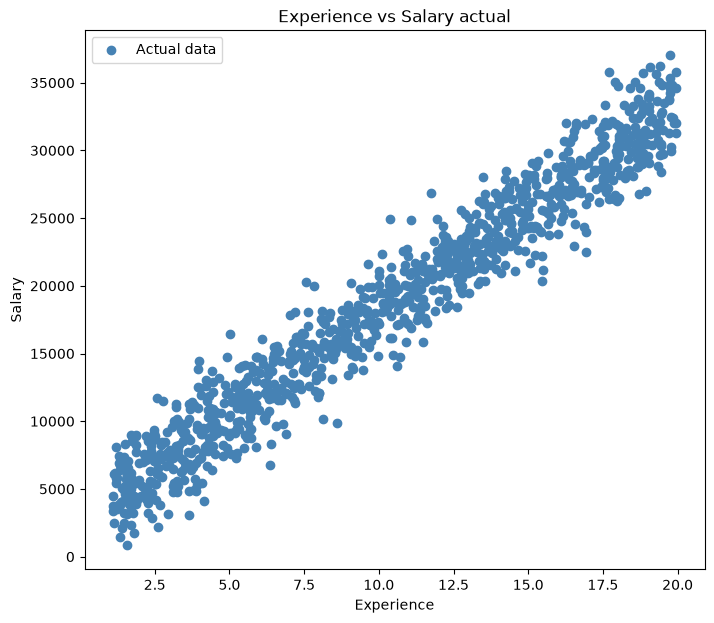

In [35]:
plt.figure(figsize=(8,7))

plt.scatter(X, Y, color="steelblue", label="Actual data")

plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Experience vs Salary actual")
plt.legend()
plt.show()

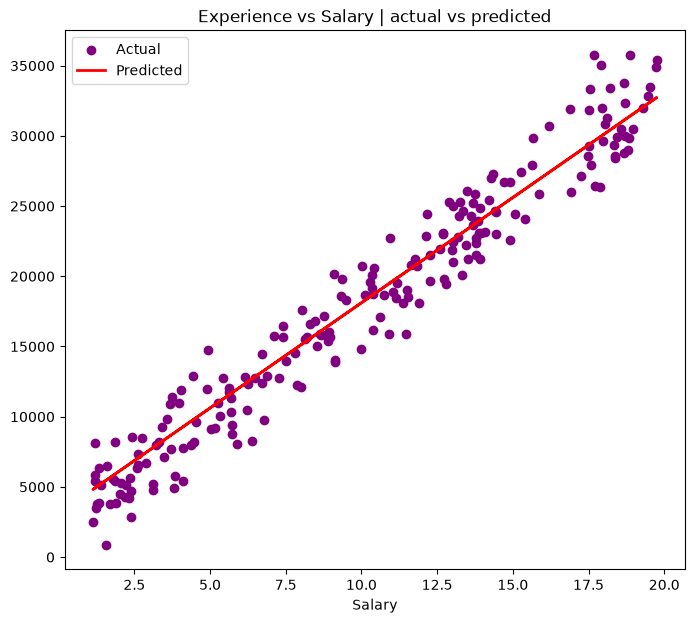

In [ ]:
plt.figure(figsize=(8,7))

plt.scatter(X_test, Y_test, color="purple", label="Actual")
plt.plot(X_test, y_pred, color="red", label="Predicted", linewidth=2)
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Experience vs Salary | actual vs predicted")
plt.legend()
plt.show()

## 4. Making predictions for new values

In [ ]:
X_full = df[["Experience_Years"]]

df["Predicted_Salary"] = model.predict(X_full)

print(df[['Experience_Years', "Salary", "Predicted_Salary"]].head(15))

    Experience_Years        Salary  Predicted_Salary
0           8.116262  10175.581957      15287.457654
1          19.063572  36177.242878      31699.781523
2          14.907885  22582.682408      25469.531126
4           3.964354  10991.672117       9062.872531
5           3.963896  13825.348642       9062.185470
7          17.457347  30313.838395      29291.711703
9          14.453379  26386.899585      24788.130983
10          1.391105   6604.515267       5205.030376
11         19.428287  32704.813635      32246.566714
13          5.034443  10426.478399      10667.161335
14          4.454674   8174.082388       9797.965845
15          4.484686   9165.678377       9842.959123
16          6.780603   9784.990296      13285.022399
17         10.970372  19258.879048      19566.369880
18          9.206955  14833.250817      16922.636437


In [ ]:
new_salary = pd.DataFrame({ "Experience_Years": [6.34335, 3.58458] })

predicted_salary = model.predict(new_salary)

print(f"The Predicted salary for the experience 6.34335 is {predicted_salary[0]}")
print(f"The Predicted salary for the experience 3.58458 is {predicted_salary[1]}")

The Predicted salary for the experience 7.34535 is 12629.488588345652
The Predicted salary for the experience 8.56458 is 8493.511026391661
